# SAM2 Segmentation Workflow

**Steps:**
1. **Configure** — set `SPK` and verify paths  
2. **Select init frame** — browse a speaker video and save the reference JPEG  
3. **Load models** — SAM2 image predictor (prompting) + video predictor (propagation)  
4. **Define regions** — edit `REGION_DEFS` with the anatomical regions to track  
5. **Prompt regions** — interactively click positive/negative points on the init frame  
6. **Test propagation** — run on a random 200-frame window; view overlay inline  
7. **Export** — write `session.json` to `sam_seg/` for use with `sam2_propagate.py`  

> **Requires** `ipycanvas` for interactive prompting: `pip install ipycanvas`

# Server Config 

1. Create server port with jupyter in tmux

```
jupyter notebook --no-browser --port=8888
```

2. Locally, create server tunnel for using GPU

```
alias gpu-tunnel="ssh -N -L 8888:localhost:8888 user@your-gpu-server.com"
```

In future runs, one can run: 

```
gpu-tunnel
```

Always need two terminals running each of these steps. 

In the notebook, add the url for the port as a new kernel. It should save and can be accessed using localhost in the future. 

In [1]:
import os, sys, json

# ── Edit these two lines ────────────────────────────────────────────────
SPK      = 'spk15'
REPO_DIR = '/data1/span_data/sam2'
# ───────────────────────────────────────────────────────────────────────

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

with open(os.path.join(REPO_DIR, 'sam2_gui_config.json')) as _f:
    _cfg = json.load(_f)

DATA_DIR     = _cfg['data_dir']
VIDEO_SUBDIR = _cfg.get('video_subdir', 'video/video')
CHECKPOINT   = os.path.join(REPO_DIR, _cfg.get('checkpoint', 'checkpoints/sam2.1_hiera_large.pt'))
MODEL_CFG    = _cfg.get('model_cfg', 'configs/sam2.1/sam2.1_hiera_l.yaml')
DEVICE_STR   = _cfg.get('device', 'cuda')

VIDEO_DIR   = os.path.join(DATA_DIR, SPK, *VIDEO_SUBDIR.split('/'))
SAM_SEG_DIR = os.path.join(DATA_DIR, SPK, 'sam_seg')
os.makedirs(SAM_SEG_DIR, exist_ok=True)

print(f'Speaker  : {SPK}')
print(f'Videos   : {VIDEO_DIR}')
print(f'Output   : {SAM_SEG_DIR}')
print(f'Device   : {DEVICE_STR}')

Speaker  : spk15
Videos   : /data1/span_data/prompt/data/mri/spk15/video/video
Output   : /data1/span_data/prompt/data/mri/spk15/sam_seg
Device   : cuda


In [49]:
!pip install ipycanvas

In [2]:
import os, json, shutil, random, tempfile
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import numpy as np
import torch
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import HBox, Label, Dropdown, ToggleButtons, Button
from ipycanvas import Canvas, hold_canvas
import cv2
from PIL import Image, ImageDraw
from IPython.display import display, Video

%matplotlib inline

device = torch.device(
    DEVICE_STR
    if DEVICE_STR == 'cpu' or (DEVICE_STR.startswith('cuda') and torch.cuda.is_available())
    else 'cpu'
)
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(device)}')

Using device: cuda
  GPU: NVIDIA RTX 6000 Ada Generation


In [3]:
from sam2.build_sam import build_sam2, build_sam2_video_predictor
from sam2.sam2_image_predictor import SAM2ImagePredictor

print('Loading SAM2 models...')
_sam2_base    = build_sam2(MODEL_CFG, CHECKPOINT, device=device)
img_predictor = SAM2ImagePredictor(_sam2_base)

vid_predictor = build_sam2_video_predictor(MODEL_CFG, CHECKPOINT, device=device)
print('Done.')

Loading SAM2 models...
Done.


## 1 — Select & Save Init Frame

Use the dropdown to pick a video, drag the slider to the desired frame, then click **Save as init frame**.

In [ ]:
video_files = sorted(f for f in os.listdir(VIDEO_DIR) if f.lower().endswith('.avi'))
if not video_files:
    raise FileNotFoundError(f'No .avi files found in {VIDEO_DIR}')
print(f'{len(video_files)} video(s) found.')

ann_frame_idx   = 0
INIT_FRAME_PATH = os.path.join(SAM_SEG_DIR, f'{SPK}_frame.jpg')

_cap    = [None]
_nf     = [0]
_out    = widgets.Output()
_status = widgets.Label('Not saved yet.')

def _load_video(vid_name):
    if _cap[0] is not None:
        _cap[0].release()
    _cap[0] = cv2.VideoCapture(os.path.join(VIDEO_DIR, vid_name))
    _nf[0]  = int(_cap[0].get(cv2.CAP_PROP_FRAME_COUNT))
    _slider.max   = _nf[0] - 1
    _slider.value = 0
    _draw_frame(0)

def _draw_frame(idx):
    cap = _cap[0]
    if cap is None:
        return
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frm = cap.read()
    if not ret:
        return
    with _out:
        _out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.imshow(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB), cmap='gray')
        ax.set_title(f'Frame {idx} / {_nf[0] - 1}')
        ax.axis('off')
        plt.tight_layout()
        plt.show()

def _on_save(_):
    global ann_frame_idx
    idx = _slider.value
    cap = _cap[0]
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frm = cap.read()
    if not ret:
        _status.value = 'Error: could not read frame.'
        return
    img = Image.fromarray(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB))
    img.save(INIT_FRAME_PATH, 'JPEG', quality=95)
    ann_frame_idx = idx
    _status.value = f'Saved frame {idx} to {INIT_FRAME_PATH}'
    print(f'ann_frame_idx = {ann_frame_idx}')

_vid_dd   = widgets.Dropdown(options=video_files, description='Video:',
                              layout=widgets.Layout(width='420px'))
_slider   = widgets.IntSlider(value=0, min=0, max=1000, step=1,
                               description='Frame:', continuous_update=False,
                               layout=widgets.Layout(width='650px'))
_save_btn = widgets.Button(description='Save as init frame', button_style='success')

_slider.observe(lambda c: _draw_frame(c['new']), names='value')
_vid_dd.observe(lambda c: _load_video(c['new']), names='value')
_save_btn.on_click(_on_save)

display(_vid_dd, _slider, widgets.HBox([_save_btn, _status]), _out)
_load_video(video_files[0])

32 video(s) found.


Dropdown(description='Video:', layout=Layout(width='420px'), options=('spk15_bvt1.avi', 'spk15_bvt2.avi', 'spk…

IntSlider(value=0, continuous_update=False, description='Frame:', layout=Layout(width='650px'), max=1000)

Output()

## 2 — Load Init Frame & Define Regions

Run the cell below to load the saved JPEG into the image predictor, then edit `REGION_DEFS` to name the regions you want to track.

Image set: (104, 104, 3)  (ann_frame_idx=0)


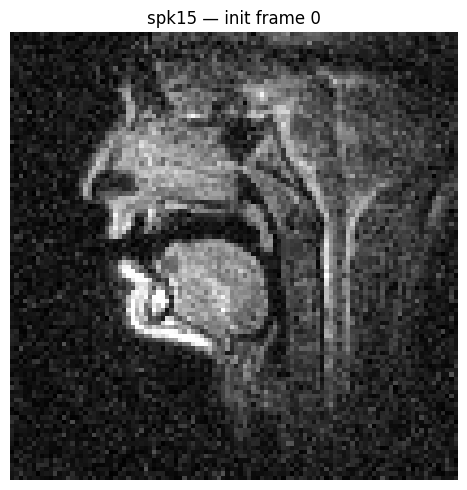

In [5]:
if not os.path.exists(INIT_FRAME_PATH):
    raise FileNotFoundError(
        f'Init frame not found: {INIT_FRAME_PATH}\nRun the frame-selection cell first.'
    )

image = np.array(Image.open(INIT_FRAME_PATH).convert('RGB'))
img_predictor.set_image(image)
print(f'Image set: {image.shape}  (ann_frame_idx={ann_frame_idx})')

fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(image, cmap='gray')
ax.set_title(f'{SPK} — init frame {ann_frame_idx}')
ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
# ── Edit this list to match your segmentation targets ────────────────────
REGION_DEFS = [
    {'name': 'lower',  'color': '#3cb44b'},
    {'name': 'upper', 'color': '#e6194b'},
]
# ─────────────────────────────────────────────────────────────────────────

for i, rd in enumerate(REGION_DEFS):
    rd['obj_id'] = i

# point store: {region_name: {'points': [[x,y],...], 'labels': [1/0,...]}}
regions = {rd['name']: {'points': [], 'labels': []} for rd in REGION_DEFS}

print('Regions:')
for rd in REGION_DEFS:
    print(f"  [{rd['obj_id']}] {rd['name']}  {rd['color']}")

Regions:
  [0] lower  #3cb44b
  [1] upper  #e6194b


In [7]:
def show_mask(mask, ax, obj_id=None):
    cmap  = plt.get_cmap('tab10')
    cidx  = 0 if obj_id is None else obj_id % 10
    color = np.array([*cmap(cidx)[:3], 0.5])
    h, w  = mask.shape[-2:]
    ax.imshow(mask.reshape(h, w, 1) * color.reshape(1, 1, 4))

def show_points(coords, labels, ax, marker_size=200):
    pos = coords[labels == 1]
    neg = coords[labels == 0]
    ax.scatter(pos[:, 0], pos[:, 1], color='green', marker='*',
               s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg[:, 0], neg[:, 1], color='red', marker='*',
               s=marker_size, edgecolor='white', linewidth=1.25)

prompts = {}

## 3 — Prompt Regions (click-based)

1. Pick a **region** from the dropdown
2. Choose **Positive (+)** or **Negative (−)** mode with the toggle
3. **Click** anywhere on the canvas image to place a point — the mask overlay updates immediately
4. Use **Clear Region** to remove all points for the selected region
5. Switch regions and repeat until all targets are marked

In [18]:
def show_mask(mask, ax, obj_id=None):
    cmap  = plt.get_cmap('tab10')
    cidx  = 0 if obj_id is None else obj_id % 10
    color = np.array([*cmap(cidx)[:3], 0.5])
    h, w  = mask.shape[-2:]
    ax.imshow(mask.reshape(h, w, 1) * color.reshape(1, 1, 4))

def show_points(coords, labels, ax, marker_size=200):
    pos = coords[labels == 1]
    neg = coords[labels == 0]
    ax.scatter(pos[:, 0], pos[:, 1], color='green', marker='*',
               s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg[:, 0], neg[:, 1], color='red', marker='*',
               s=marker_size, edgecolor='white', linewidth=1.25)

# ── canvas setup ─────────────────────────────────────────────────────────
h_img, w_img = image.shape[:2]

DISPLAY_MAX = 600  # max canvas dimension in pixels
_scale = min(DISPLAY_MAX / w_img, DISPLAY_MAX / h_img)
c_w = int(w_img * _scale)
c_h = int(h_img * _scale)

canvas = Canvas(width=c_w, height=c_h)
_cmap  = plt.get_cmap('tab10')

def _region_color_rgba(obj_id, alpha=120):
    r, g, b, _ = _cmap(obj_id % 10)
    return (int(r*255), int(g*255), int(b*255), alpha)

def _redraw_canvas():
    base    = Image.fromarray(image).convert('RGBA')
    overlay = Image.new('RGBA', base.size, (0, 0, 0, 0))

    for rd in REGION_DEFS:
        r = regions[rd['name']]
        if not r['points']:
            continue
        pts = np.array(r['points'], dtype=np.float32)
        lbs = np.array(r['labels'], np.int32)
        try:
            masks, _, _ = img_predictor.predict(
                point_coords=pts, point_labels=lbs, multimask_output=False
            )
        except Exception:
            continue
        mask      = masks[0].astype(bool)
        color     = _region_color_rgba(rd['obj_id'])
        mask_rgba = np.zeros((h_img, w_img, 4), dtype=np.uint8)
        mask_rgba[mask] = color
        overlay = Image.alpha_composite(overlay, Image.fromarray(mask_rgba, mode='RGBA'))

    composite = Image.alpha_composite(base, overlay)

    draw  = ImageDraw.Draw(composite)
    r_dot = int(dot_slider.value / _scale)
    for rd in REGION_DEFS:
        r = regions[rd['name']]
        for (x, y), lbl in zip(r['points'], r['labels']):
            fill = (0, 220, 0, 255) if lbl == 1 else (220, 0, 0, 255)
            draw.ellipse([x - r_dot, y - r_dot, x + r_dot, y + r_dot],
                         fill=fill, outline='white', width=max(1, r_dot // 3))

    display_img = composite.resize((c_w, c_h), Image.LANCZOS)
    with hold_canvas(canvas):
        canvas.clear()
        canvas.put_image_data(np.array(display_img), 0, 0)

def on_mouse_down(x, y):
    img_x = x / _scale
    img_y = y / _scale
    name  = region_dd.value
    lbl   = 1 if mode_tog.value == 'Positive (+)' else 0
    regions[name]['points'].append([float(img_x), float(img_y)])
    regions[name]['labels'].append(lbl)
    n = len(regions[name]['points'])
    status_lbl.value = f'{name}: {n} point(s)'
    _redraw_canvas()

def on_undo(btn):
    name = region_dd.value
    r    = regions[name]
    if r['points']:
        r['points'].pop()
        r['labels'].pop()
        n = len(r['points'])
        status_lbl.value = f'{name}: {n} point(s) (undone)'
        _redraw_canvas()
    else:
        status_lbl.value = f'{name}: nothing to undo'

def on_clear(btn):
    name = region_dd.value
    regions[name]['points'].clear()
    regions[name]['labels'].clear()
    status_lbl.value = f'{name}: cleared'
    _redraw_canvas()

# ── widgets ───────────────────────────────────────────────────────────────
region_dd  = Dropdown(
    options=[rd['name'] for rd in REGION_DEFS],
    description='Region:',
    layout=widgets.Layout(width='260px'),
)
mode_tog   = ToggleButtons(
    options=['Positive (+)', 'Negative (−)'],
    value='Positive (+)',
    description='Mode:',
    button_style='',
)
dot_slider = widgets.IntSlider(
    value=4, min=1, max=20, step=1,
    description='Dot size:',
    continuous_update=False,
    layout=widgets.Layout(width='320px'),
)
undo_btn   = widgets.Button(description='Undo', button_style='info')
clear_btn  = widgets.Button(description='Clear Region', button_style='warning')
status_lbl = Label('Select mode and click on the image.')

canvas.on_mouse_down(on_mouse_down)
undo_btn.on_click(on_undo)
clear_btn.on_click(on_clear)
dot_slider.observe(lambda _: _redraw_canvas(), names='value')

display(HBox([region_dd, mode_tog]))
display(HBox([dot_slider, undo_btn, clear_btn, status_lbl]))
display(canvas)
print(f'Image: {w_img}×{h_img} px  →  display: {c_w}×{c_h} px  (scale ×{_scale:.2f})')
_redraw_canvas()

Canvas(height=600, width=600)

Image: 104×104 px  →  display: 600×600 px  (scale ×5.77)


## 3 — Alternative - Prompt Regions

Set `ann_obj_id`, `points`, and `labels` in the cell below and run it to preview the mask.  
**Duplicate the cell** for each region. `obj_id` must match the corresponding entry in `REGION_DEFS`.

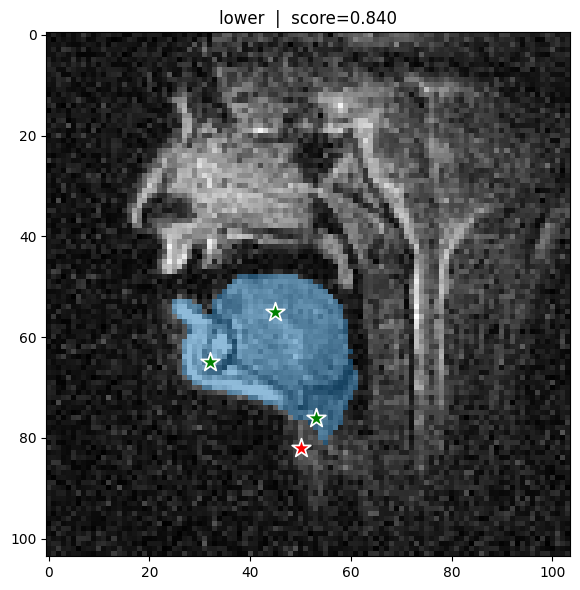

In [45]:
### REGION 1 ###

# ── Edit these for each region — duplicate this cell per region ──────────
ann_obj_id = 0
points     = np.array([[45, 55], [32, 65], [53, 76], [50, 82]], dtype=np.float32)
labels     = np.array([1, 1, 1,0], np.int32)   # 1=positive, 0=negative
# ─────────────────────────────────────────────────────────────────────────

prompts[ann_obj_id] = points, labels

masks, scores, _ = img_predictor.predict(
    point_coords=points,
    point_labels=labels,
    multimask_output=False,
)

# store in regions dict for export
_rd = next((r for r in REGION_DEFS if r['obj_id'] == ann_obj_id), None)
if _rd:
    regions[_rd['name']]['points'] = points.tolist()
    regions[_rd['name']]['labels'] = labels.tolist()

plt.figure(figsize=(9, 6))
plt.title(f"{_rd['name'] if _rd else ann_obj_id}  |  score={scores[0]:.3f}")
plt.imshow(image, cmap='gray')
show_points(points, labels, plt.gca())
show_mask(masks[0], plt.gca(), obj_id=ann_obj_id)
#plt.axis('off')
plt.tight_layout()
plt.show()

## 4 — Test Propagation

Randomly samples 200 consecutive frames from the speaker's videos, propagates the prompts defined above, and plays the overlay video inline.

In [21]:
import subprocess

N_SAMPLE    = 200
MASK_OPACITY = 0.6  # 0.0 = invisible, 1.0 = fully opaque

active = [rd for rd in REGION_DEFS if regions[rd['name']]['points']]
if not active:
    raise RuntimeError('No regions have points yet. Complete the prompting cells first.')
print(active)

# ── pick a random video + frame window ──────────────────────────────────
test_vid  = random.choice(video_files)
test_path = os.path.join(VIDEO_DIR, test_vid)

_tc = cv2.VideoCapture(test_path)
n_total = int(_tc.get(cv2.CAP_PROP_FRAME_COUNT))
fps_vid  = _tc.get(cv2.CAP_PROP_FPS) or 25.0
h_vid    = int(_tc.get(cv2.CAP_PROP_FRAME_HEIGHT))
w_vid    = int(_tc.get(cv2.CAP_PROP_FRAME_WIDTH))
_tc.release()

n_sample  = min(N_SAMPLE, n_total)
start_idx = random.randint(0, max(0, n_total - n_sample))
end_idx   = start_idx + n_sample

print(f'Video   : {test_vid}  ({n_total} frames @ {fps_vid:.1f} fps)')
print(f'Window  : frames {start_idx}-{end_idx - 1}  ({n_sample} frames)')

# ── extract frames to temp dir ───────────────────────────────────────────
_tmp = tempfile.mkdtemp(prefix='sam2_test_')
_tc2 = cv2.VideoCapture(test_path)
_tc2.set(cv2.CAP_PROP_POS_FRAMES, start_idx)
for i in range(n_sample):
    ret, frm = _tc2.read()
    if not ret:
        break
    cv2.imwrite(os.path.join(_tmp, f'{i:05d}.jpg'), frm,
                [cv2.IMWRITE_JPEG_QUALITY, 95])
_tc2.release()
print(f'Frames extracted to {_tmp}')

# ── SAM2 propagation ─────────────────────────────────────────────────────
state = vid_predictor.init_state(
    video_path=_tmp, offload_video_to_cpu=True, offload_state_to_cpu=False,
)
vid_predictor.reset_state(state)

for rd in active:
    r = regions[rd['name']]
    vid_predictor.add_new_points_or_box(
        state, frame_idx=0, obj_id=rd['obj_id'],
        points=np.array(r['points'], dtype=np.float32),
        labels=np.array(r['labels'],  np.int32),
        clear_old_points=True,
    )

print('Propagating...')
segs = {}
for fid, oids, logits in vid_predictor.propagate_in_video(state):
    segs[fid] = {oid: (logits[i] > 0).cpu().numpy() for i, oid in enumerate(oids)}
print(f'Done — {len(segs)} frames segmented.')

# ── render overlay (mp4v scratch file) ───────────────────────────────────
def _hex_bgr(h):
    h = h.lstrip('#')
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return np.array([b, g, r], dtype=np.float32)

_raw_path = os.path.join(SAM_SEG_DIR, f'{SPK}_test_prop_raw.mp4')
_writer = cv2.VideoWriter(_raw_path, cv2.VideoWriter_fourcc(*'mp4v'), fps_vid, (w_vid, h_vid))
_tc3 = cv2.VideoCapture(test_path)
_tc3.set(cv2.CAP_PROP_POS_FRAMES, start_idx)

for i in range(n_sample):
    ret, frm = _tc3.read()
    if not ret:
        break
    canvas = frm.astype(np.float32)
    if i in segs:
        for rd in active:
            mask = segs[i].get(rd['obj_id'])
            if mask is None:
                continue
            m = np.squeeze(mask).astype(bool)
            if m.shape != (h_vid, w_vid):
                continue
            canvas[m] = (1 - MASK_OPACITY) * canvas[m] + MASK_OPACITY * _hex_bgr(rd['color'])
    _writer.write(canvas.astype(np.uint8))

_tc3.release()
_writer.release()
shutil.rmtree(_tmp)

# ── re-encode to H.264 so the browser can play it ────────────────────────
overlay_path = os.path.join(SAM_SEG_DIR, f'{SPK}_test_prop.mp4')
subprocess.run(
    ['ffmpeg', '-y', '-i', _raw_path,
     '-vcodec', 'libx264', '-pix_fmt', 'yuv420p', '-crf', '23',
     overlay_path],
    check=True, capture_output=True,
)
os.remove(_raw_path)
print(f'Overlay saved to {overlay_path}')

display(Video(overlay_path, embed=True, width=700))

[{'name': 'lower', 'color': '#3cb44b', 'obj_id': 0}, {'name': 'upper', 'color': '#e6194b', 'obj_id': 1}]
Video   : spk15_stops.avi  (1836 frames @ 99.0 fps)
Window  : frames 852-1051  (200 frames)
Frames extracted to /tmp/sam2_test_w7ktead7


frame loading (JPEG): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 62.98it/s]


Propagating...


propagate in video: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:32<00:00,  6.17it/s]


Done — 200 frames segmented.
Overlay saved to /data1/span_data/prompt/data/mri/spk15/sam_seg/spk15_test_prop.mp4


In [27]:
import subprocess, tempfile, shutil, json, random                                                                                                           
import cv2                                                                                                                                                  
import numpy as np                                                                                                                                          
from IPython.display import display, Video                                                                                                                  
                                                                                                                                                            
SESSION_PATH = '/data1/span_data/prompt/data/mri/spk15/sam_seg/session.json'  # ← edit this                                                                                                       
MASK_OPACITY = 0.7
N_SAMPLE     = 200                                                                                                                                          
                                                                                                                                                            
with open(SESSION_PATH) as f:
    sess = json.load(f)                                                                                                                                     
                                                        
active_regions = sess['regions']                                                                                                                            
init_frame_idx = sess['initial_frame_idx']
                                                                                                                                                            
# ── pick a random video + frame window ──────────────────────────────────                                                                                  
test_vid  = random.choice(video_files)                                                                                                                      
test_path = os.path.join(VIDEO_DIR, test_vid)                                                                                                               
                                                                                                                                                            
_tc     = cv2.VideoCapture(test_path)
n_total = int(_tc.get(cv2.CAP_PROP_FRAME_COUNT))                                                                                                            
fps_vid = _tc.get(cv2.CAP_PROP_FPS) or 25.0                                                                                                                 
h_vid   = int(_tc.get(cv2.CAP_PROP_FRAME_HEIGHT))                                                                                                           
w_vid   = int(_tc.get(cv2.CAP_PROP_FRAME_WIDTH))                                                                                                            
_tc.release()                                                                                                                                               
                                                                                                                                                            
n_sample  = min(N_SAMPLE, n_total)                                                                                                                          
start_idx = random.randint(0, max(0, n_total - n_sample)) 
print(f'Video : {test_vid}  ({n_total} frames @ {fps_vid:.1f} fps)')                                                                                        
print(f'Window: {start_idx}–{start_idx + n_sample - 1}')                                                                                                    
                                                                                                                                                            
# ── extract frames ───────────────────────────────────────────────────────                                                                                 
_tmp = tempfile.mkdtemp(prefix='sam2_sess_test_')                                                                                                           
_tc2 = cv2.VideoCapture(test_path)                                                                                                                          
_tc2.set(cv2.CAP_PROP_POS_FRAMES, start_idx)              
for i in range(n_sample):                                                                                                                                   
    ret, frm = _tc2.read()                                
    if not ret:                                                                                                                                             
        break                                             
    cv2.imwrite(os.path.join(_tmp, f'{i:05d}.jpg'), frm, [cv2.IMWRITE_JPEG_QUALITY, 95])                                                                    
_tc2.release()                                                                                                                                              
                                                                                                                                                            
# ── SAM2 propagation with session.json points ────────────────────────────                                                                                 
state = vid_predictor.init_state(video_path=_tmp, offload_video_to_cpu=True, offload_state_to_cpu=False)                                                    
vid_predictor.reset_state(state)                                                                                                                            
                                                        
for r in active_regions:                                                                                                                                    
    if not r['points']:                                   
        continue                                                                                                                                            
    vid_predictor.add_new_points_or_box(
        state, frame_idx=0, obj_id=r['obj_id'],                                                                                                             
        points=np.array(r['points'], dtype=np.float32),                                                                                                     
        labels=np.array(r['labels'],  dtype=np.int32),                                                                                                      
        clear_old_points=True,                                                                                                                              
    )                                                                                                                                                       
    print(f"  {r['name']}: {sum(r['labels'])} pos / {r['labels'].count(0)} neg points")
                                                                                                                                                            
print('Propagating...')                                                                                                                                     
segs = {}                                                                                                                                                   
for fid, oids, logits in vid_predictor.propagate_in_video(state):                                                                                           
    segs[fid] = {oid: (logits[i] > 0).cpu().numpy() for i, oid in enumerate(oids)}                                                                          
                                                                                                                                                            
for fid in [0, 1, 10]:                                                                                                                                      
    if fid in segs:                                                                                                                                         
        for r in active_regions:                                                                                                                            
            m = np.squeeze(segs[fid].get(r['obj_id'], np.zeros((1,h_vid,w_vid)))).astype(bool)
            print(f"  frame {fid}  {r['name']}: {m.mean():.3f}")                                                                                            
                                                                                                                                                            
# ── render overlay ───────────────────────────────────────────────────────                                                                                 
def _hex_bgr(h):                                                                                                                                            
    h = h.lstrip('#')                                                                                                                                       
    r, g, b = int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)
    return np.array([b, g, r], dtype=np.float32)                                                                                                            
                                                                                                                                                            
_raw = os.path.join(SAM_SEG_DIR, f'{SPK}_sesstest_raw.mp4')                                                                                                 
_writer = cv2.VideoWriter(_raw, cv2.VideoWriter_fourcc(*'mp4v'), fps_vid, (w_vid, h_vid))                                                                   
_tc3 = cv2.VideoCapture(test_path)                                                                                                                          
_tc3.set(cv2.CAP_PROP_POS_FRAMES, start_idx)                                                                                                                
for i in range(n_sample):                                                                                                                                   
    ret, frm = _tc3.read()                                                                                                                                  
    if not ret:                                                                                                                                             
        break                                                                                                                                               
    canvas = frm.astype(np.float32)                       
    if i in segs:                                                                                                                                           
        for r in active_regions:
            mask = segs[i].get(r['obj_id'])                                                                                                                 
            if mask is None:                                                                                                                                
                continue                                                                                                                                    
            m = np.squeeze(mask).astype(bool)                                                                                                               
            if m.shape != (h_vid, w_vid):                 
                continue                                                                                                                                    
            canvas[m] = (1 - MASK_OPACITY) * canvas[m] + MASK_OPACITY * _hex_bgr(r['color'])
    _writer.write(canvas.astype(np.uint8))                                                                                                                  
_tc3.release()                                                                                                                                              
_writer.release()                                                                                                                                           
shutil.rmtree(_tmp)                                                                                                                                         
                                                        
out_path = os.path.join(SAM_SEG_DIR, f'{SPK}_sesstest.mp4')                                                                                                 
subprocess.run(['ffmpeg', '-y', '-i', _raw, '-vcodec', 'libx264', '-pix_fmt', 'yuv420p', '-crf', '23', out_path],
                check=True, capture_output=True)                                                                                                             
os.remove(_raw)                                           
print(f'Saved: {out_path}')                                                                                                                                 
display(Video(out_path, embed=True, width=700))   

Video : spk15_coartic2.avi  (1777 frames @ 99.0 fps)
Window: 1530–1729


frame loading (JPEG): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 63.96it/s]


  lower: 12 pos / 2 neg points
  upper: 12 pos / 12 neg points
Propagating...


propagate in video: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:31<00:00,  6.30it/s]


  frame 0  lower: 0.086
  frame 0  upper: 0.036
  frame 1  lower: 0.082
  frame 1  upper: 0.036
  frame 10  lower: 0.089
  frame 10  upper: 0.037
Saved: /data1/span_data/prompt/data/mri/spk15/sam_seg/spk15_sesstest.mp4


In [28]:
import cv2, numpy as np                                                                                                                                     
                                                                                                                                                            
ffmpeg_frame = cv2.imread('/tmp/sam2_frames/spk15/spk15_picture_description1/00000.jpg')                                                                    
                                                        
cap = cv2.VideoCapture('/data1/span_data/prompt/data/mri/spk15/video/video/spk15_picture_description1.avi')                                                 
ret, cv2_frame = cap.read()                               
cap.release()                                                                                                                                               
                                                        
print('ffmpeg frame:', ffmpeg_frame.shape, ffmpeg_frame.dtype, ffmpeg_frame.mean())                                                                         
print('cv2 frame:   ', cv2_frame.shape,   cv2_frame.dtype,   cv2_frame.mean())
print('max diff:', np.abs(ffmpeg_frame.astype(int) - cv2_frame.astype(int)).max())      

ffmpeg frame: (104, 104, 3) uint8 69.66309171597634
cv2 frame:    (104, 104, 3) uint8 69.69905695266272
max diff: 10


## 5 — Export Session JSON

Saves all region prompts and the init-frame index to `sam_seg/session.json`.  
This file is consumed by `sam2_propagate.py`.

In [22]:
active = [rd for rd in REGION_DEFS if regions[rd['name']]['points']]
if not active:
    raise RuntimeError('No prompts found. Complete the prompting cell first.')

session = {
    'speaker':           SPK,
    'initial_frame_idx': ann_frame_idx,
    'regions': [
        {
            'name':   rd['name'],
            'obj_id': rd['obj_id'],
            'color':  rd['color'],
            'points': regions[rd['name']]['points'],
            'labels': regions[rd['name']]['labels'],
        }
        for rd in active
    ],
}

session_path = os.path.join(SAM_SEG_DIR, 'session.json')
with open(session_path, 'w') as f:
    json.dump(session, f, indent=2)

print(f'Session saved to {session_path}')
print()
print(json.dumps(session, indent=2))
print()
print(f'To propagate across all videos run:')
print(f'  python sam2_propagate.py --session {session_path}')

Session saved to /data1/span_data/prompt/data/mri/spk15/sam_seg/session.json

{
  "speaker": "spk15",
  "initial_frame_idx": 0,
  "regions": [
    {
      "name": "lower",
      "obj_id": 0,
      "color": "#3cb44b",
      "points": [
        [
          36.57333333333333,
          54.6
        ],
        [
          46.28,
          58.93333333333334
        ],
        [
          26.866666666666667,
          55.12
        ],
        [
          34.32,
          63.61333333333334
        ],
        [
          55.64,
          65.0
        ],
        [
          52.346666666666664,
          54.946666666666665
        ],
        [
          43.68,
          66.90666666666667
        ],
        [
          51.82666666666667,
          73.84
        ],
        [
          58.24,
          71.76
        ],
        [
          33.626666666666665,
          68.29333333333334
        ],
        [
          50.78666666666667,
          79.56
        ],
        [
          55.12,
          

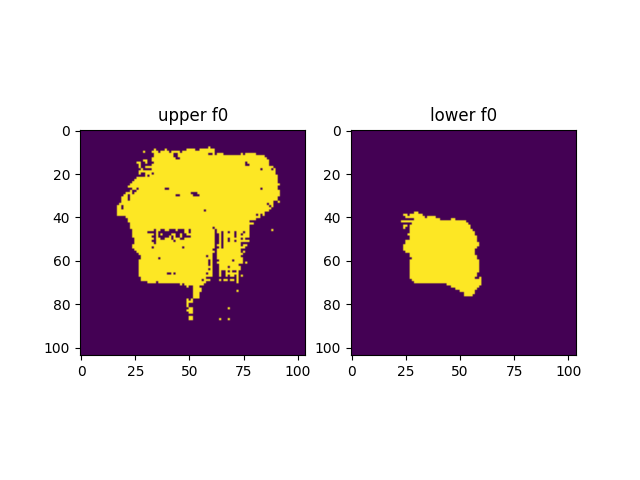

In [24]:
from IPython.display import Image                                                                                                                           
Image('/tmp/masks_f0.png') 

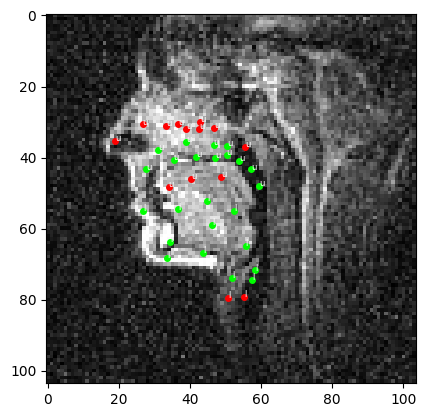

In [26]:
  import cv2, json, numpy as np, matplotlib.pyplot as plt                                                                                                     
                                                                                                                                                              
  frame = cv2.imread('/tmp/sam2_frames/spk15/spk15_picture_description1/00000.jpg')                                                                           
  frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)                                                                                                          
                                                                                                                                                              
  with open('/data1/span_data/prompt/data/mri/spk15/sam_seg/session.json') as f:
      session = json.load(f)                                                                                                                                  
                                                            
  fig, ax = plt.subplots()                                                                                                                                    
  ax.imshow(frame_rgb)
  for region in session['regions']:                                                                                                                           
      for (x, y), lbl in zip(region['points'], region['labels']):
          color = 'lime' if lbl == 1 else 'red'                                                                                                               
          ax.plot(x, y, 'o', color=color, markersize=4)                                                                                                       
          ax.text(x, y, region['name'][0], fontsize=6, color='white')                                                                                         
  plt.savefig('/tmp/frame0_points.png')   